# Step 3 - Visualize Features And Prepare For Power BI

This notebook checks which features line up with delays and exports a cleaned file for Power BI.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

## Load And Clean Data


In [2]:
data_dir = Path("../data/raw/flight/2022")
csv_files = sorted(data_dir.glob("2022-0[1-3]_flight.csv"))

cols = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "DepDelay",
    "Cancelled"
]

dfs = []

for file in csv_files:
    df_part = pd.read_csv(file, usecols=cols)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)
df.shape

(1598468, 8)

In [3]:
df = df[df["Cancelled"] == 0].copy()

df = df.dropna(subset=[
    "DepDelay",
    "CRSDepTime",
    "Reporting_Airline",
    "Origin",
    "Dest"
])

df = df.sample(n=200_000, random_state=42)

df["Delay"] = (df["DepDelay"] > 15).astype(int)

df = df.drop(columns=["DepDelay"])

df["CRSDepTime"] = df["CRSDepTime"].astype(int)
df["dep_hour"] = df["CRSDepTime"] // 100

df.shape

(200000, 9)

## Create Visualization Features


In [4]:
df["route"] = df["Origin"] + "_" + df["Dest"]
df["is_weekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)

df["time_of_day_bin"] = pd.cut(
    df["dep_hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["overnight", "morning", "afternoon", "evening", "night"]
)

df.head()

,Month,DayOfWeek,Reporting_Airline,Origin,Dest,CRSDepTime,Cancelled,Delay,dep_hour,route,is_weekend,time_of_day_bin
1520653,3,7,AA,DFW,ABQ,1316,0.0,0,13,DFW_ABQ,1,afternoon
344435,1,2,WN,SAN,PHX,1415,0.0,0,14,SAN_PHX,0,afternoon
399849,1,5,YX,JFK,BWI,1329,0.0,0,13,JFK_BWI,0,afternoon
210583,1,4,HA,LAX,KOA,1110,0.0,0,11,LAX_KOA,0,morning
1241754,3,4,F9,DEN,ORD,2012,0.0,1,20,DEN_ORD,0,evening


## Delay Class Balance


In [5]:
delay_balance = df["Delay"].value_counts(normalize=True).sort_index()
delay_balance

Delay
0    0.803215
1    0.196785
Name: proportion, dtype: float64

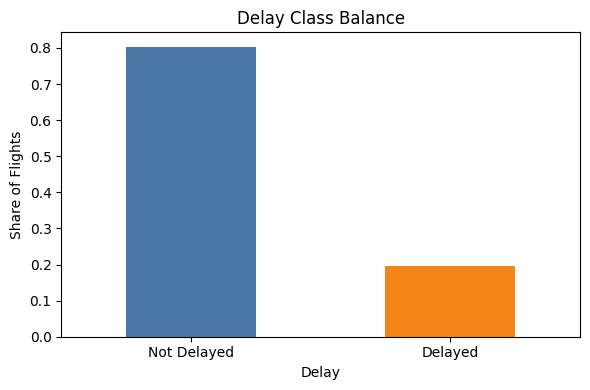

In [6]:
ax = delay_balance.plot(kind="bar", figsize=(6, 4), color=["#4C78A8", "#F58518"])
ax.set_title("Delay Class Balance")
ax.set_xlabel("Delay")
ax.set_ylabel("Share of Flights")
ax.set_xticklabels(["Not Delayed", "Delayed"], rotation=0)
plt.tight_layout()
plt.show()

## Correlation Matrix


In [7]:
corr_cols = [
    "Month",
    "DayOfWeek",
    "CRSDepTime",
    "dep_hour",
    "is_weekend",
    "Delay"
]

corr = df[corr_cols].corr()
corr

,Month,DayOfWeek,CRSDepTime,dep_hour,is_weekend,Delay
Month,1.000000,-0.020628,-0.000138,-0.000267,-0.044218,0.020058
DayOfWeek,-0.020628,1.000000,0.009478,0.009452,0.789331,0.057638
CRSDepTime,-0.000138,0.009478,1.000000,0.999307,0.003698,0.143166
dep_hour,-0.000267,0.009452,0.999307,1.000000,0.003733,0.142680
is_weekend,-0.044218,0.789331,0.003698,0.003733,1.000000,0.047159
Delay,0.020058,0.057638,0.143166,0.142680,0.047159,1.000000


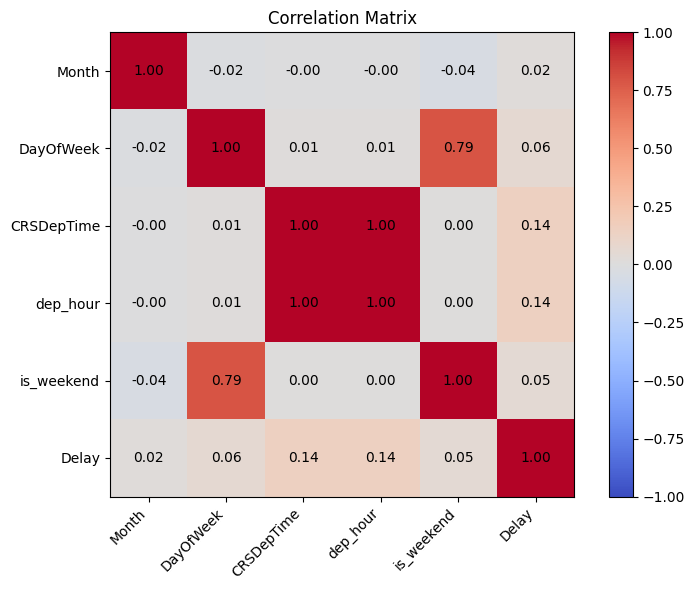

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Delay Rate By Feature


In [9]:
def plot_delay_rate_by_feature(data, feature, title, top_n=None, min_flights=0):
    grouped = (
        data.groupby(feature, observed=True)
        .agg(delay_rate=("Delay", "mean"), flights=("Delay", "size"))
        .reset_index()
    )

    if min_flights:
        grouped = grouped[grouped["flights"] >= min_flights]

    if top_n:
        grouped = grouped.sort_values("flights", ascending=False).head(top_n)

    grouped = grouped.sort_values("delay_rate", ascending=False)

    ax = grouped.plot(
        x=feature,
        y="delay_rate",
        kind="bar",
        figsize=(10, 5),
        legend=False,
        color="#4C78A8"
    )
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Delay Rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return grouped

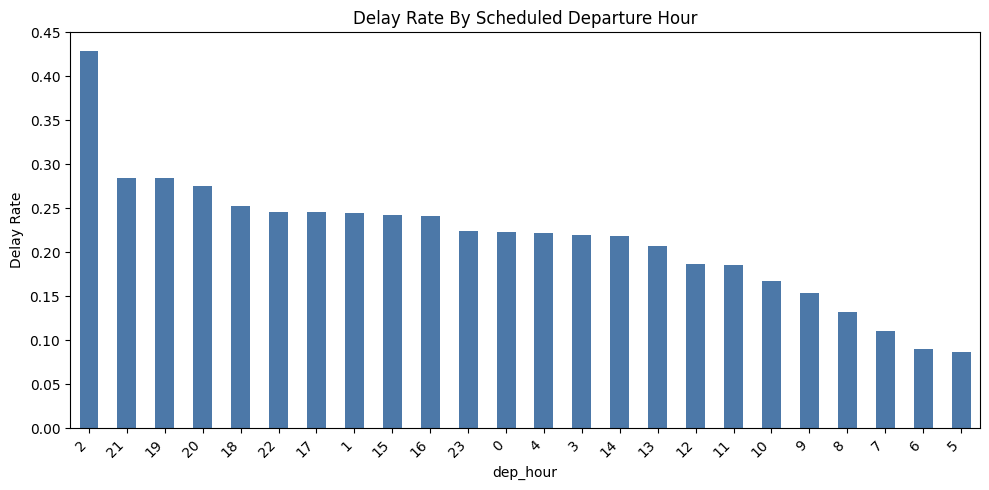

,dep_hour,delay_rate,flights
2,2,0.428571,56
21,21,0.284816,6046
19,19,0.284200,10475
20,20,0.275653,9073
18,18,0.252508,11964
22,22,0.245291,4990
17,17,0.245201,12659
1,1,0.244094,127
15,15,0.242624,11829
16,16,0.241018,11551


In [10]:
hour_delay = plot_delay_rate_by_feature(
    df,
    feature="dep_hour",
    title="Delay Rate By Scheduled Departure Hour"
)
hour_delay

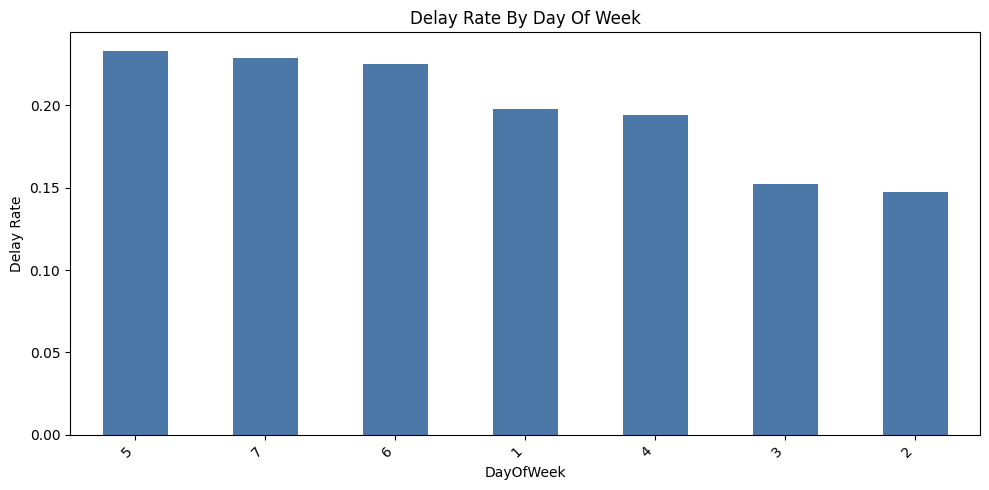

,DayOfWeek,delay_rate,flights
4,5,0.232804,27942
6,7,0.229049,29688
5,6,0.225078,25329
0,1,0.198153,30542
3,4,0.194248,30286
2,3,0.152201,27917
1,2,0.147265,28296


In [11]:
day_delay = plot_delay_rate_by_feature(
    df,
    feature="DayOfWeek",
    title="Delay Rate By Day Of Week"
)
day_delay

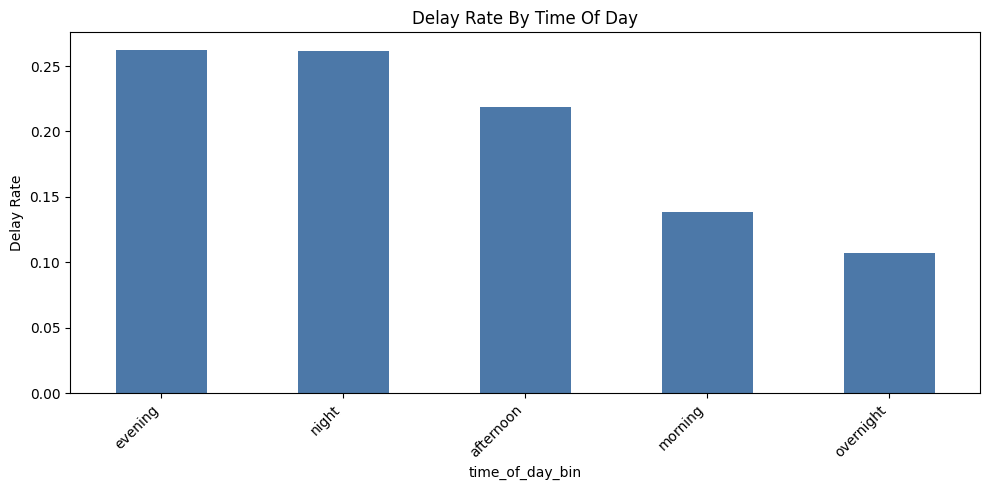

,time_of_day_bin,delay_rate,flights
3,evening,0.262684,44171
4,night,0.261627,12579
2,afternoon,0.218503,59688
1,morning,0.138576,78477
0,overnight,0.107375,5085


In [12]:
time_bin_delay = plot_delay_rate_by_feature(
    df,
    feature="time_of_day_bin",
    title="Delay Rate By Time Of Day"
)
time_bin_delay

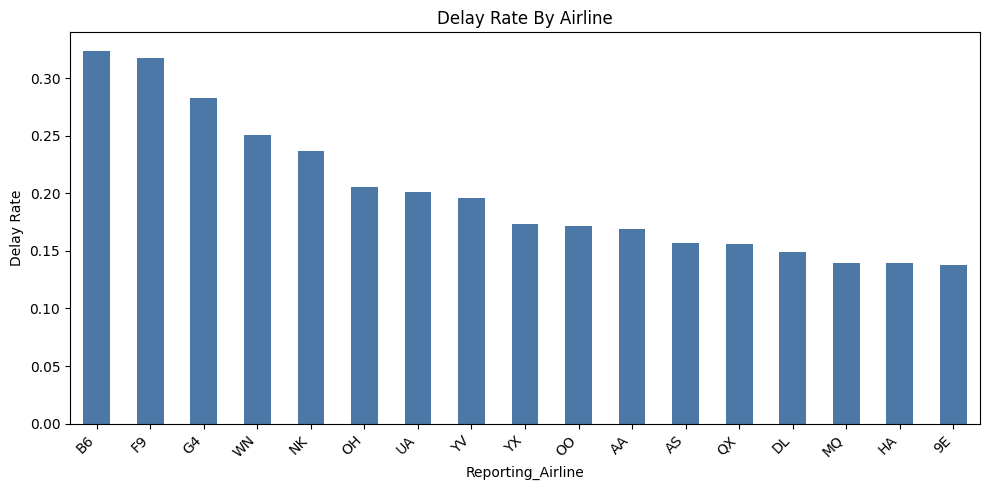

,Reporting_Airline,delay_rate,flights
3,B6,0.323466,7939
5,F9,0.317171,4496
6,G4,0.282215,3593
14,WN,0.250178,36518
9,NK,0.236877,6725
10,OH,0.205209,7334
13,UA,0.200623,17645
15,YV,0.195773,3785
16,YX,0.173196,10006
11,OO,0.171806,22246


In [13]:
airline_delay = plot_delay_rate_by_feature(
    df,
    feature="Reporting_Airline",
    title="Delay Rate By Airline",
    min_flights=500
)
airline_delay

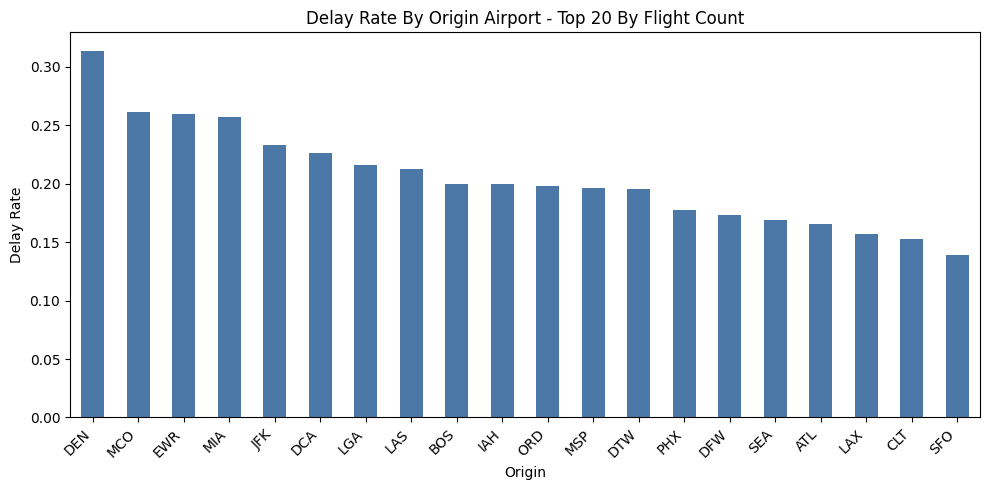

,Origin,delay_rate,flights
93,DEN,0.313605,7806
210,MCO,0.261283,4520
116,EWR,0.259648,3809
221,MIA,0.256720,3646
177,JFK,0.233375,4015
90,DCA,0.226099,4184
197,LGA,0.216174,5107
186,LAS,0.212710,4941
44,BOS,0.199680,3746
163,IAH,0.199316,3803


In [14]:
origin_delay = plot_delay_rate_by_feature(
    df,
    feature="Origin",
    title="Delay Rate By Origin Airport - Top 20 By Flight Count",
    top_n=20,
    min_flights=500
)
origin_delay

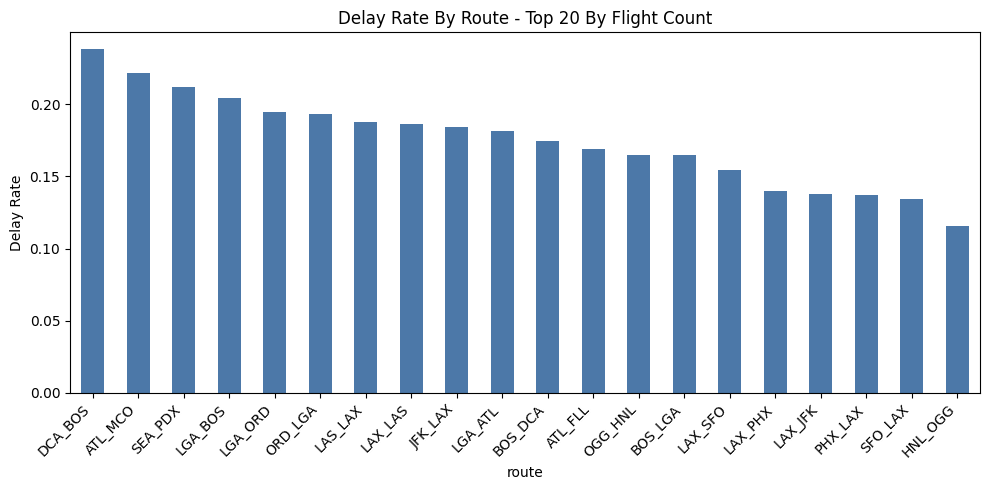

,route,delay_rate,flights
1259,DCA_BOS,0.237960,353
200,ATL_MCO,0.221757,239
5064,SEA_PDX,0.212000,250
3083,LGA_BOS,0.204082,245
3125,LGA_ORD,0.194969,318
4025,ORD_LGA,0.193548,372
2883,LAS_LAX,0.187726,277
2992,LAX_LAS,0.186380,279
2751,JFK_LAX,0.184211,304
3078,LGA_ATL,0.181132,265


In [15]:
route_delay = plot_delay_rate_by_feature(
    df,
    feature="route",
    title="Delay Rate By Route - Top 20 By Flight Count",
    top_n=20,
    min_flights=200
)
route_delay

## Export For Power BI


In [16]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

power_bi_cols = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "dep_hour",
    "route",
    "is_weekend",
    "time_of_day_bin",
    "Delay"
]

power_bi_path = processed_dir / "flight_delay_power_bi_sample.csv"
df[power_bi_cols].to_csv(power_bi_path, index=False)

power_bi_path

WindowsPath('../data/processed/flight_delay_power_bi_sample.csv')